# EViT-ToMe Hybrid Token Reduction Testing & Visualization (ImageNet-100)

This notebook tests the **EViT-then-ToMe hybrid** token reduction strategy and provides visualizations of:
- Which patches are kept vs. fused by EViT at each reduction layer
- Which tokens are merged by ToMe after EViT fusion
- Combined two-stage token reduction statistics through the network
- Performance vs. accuracy trade-offs
- Ablations: EViT-only, ToMe-only, and Hybrid at matched total budgets
- Comparison across keep-rate schedules and reduction locations

**Hybrid Strategy**: EViT first scores patches by CLS-attention and fuses low-attention tokens into one extra token; ToMe then merges similar surviving token pairs via bipartite soft-matching. Both stages run within the same block from a single QKV computation, controlled by independent keep-rate schedules.

In [5]:
# If running in a fresh Colab runtime, uncomment these lines:
!git clone https://github.com/Chalhotra/ViT-Token-Economy.git
%cd ViT-Token-Economy

Cloning into 'ViT-Token-Economy'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 431 (delta 137), reused 131 (delta 79), pack-reused 221 (from 1)
Receiving objects: 100% (431/431), 2.92 MiB | 11.06 MiB/s, done.
Resolving deltas: 100% (260/260), done.
/content/ViT-Token-Economy


In [6]:
!git checkout priyanshu/progressive-testing

Branch 'priyanshu/progressive-testing' set up to track remote branch 'priyanshu/progressive-testing' from 'origin'.
Switched to a new branch 'priyanshu/progressive-testing'


In [7]:
!pip -q install -r requirements.txt
!pip -q install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vit-deit-baselines (pyproject.toml) ... done


In [8]:
# Import core modules
from src.imagenet_mapping import build_imagenet100_to_1k_map
from src.models import ModelConfig, create_model, shrink_imagenet1k_head_to_imagenet100
from src.data import DataConfig, load_imagenet100_split, build_transform_for_model, apply_timm_preprocess, build_loader
from src.eval import evaluate_accuracy_latency_throughput, compute_gflops
from src.utils import get_device, num_params
from src.test_models.evit_tome import (
    EVITToMeConfig, apply_evit_tome_pruning,
    BlockHybridAdapter,
    )
# Individual methods for ablation baselines
from src.test_models.evit import EVITConfig, apply_evit_pruning
from src.test_models.tome import ToMeConfig, apply_tome_merging
import torch

# Visualization
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingModuleSource]
import numpy as np
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from typing import List, Dict
import pandas as pd

HYBRID_CONFIG_ORDER = []

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [9]:
device = get_device()
maps = build_imagenet100_to_1k_map()
print(f"Using device: {device}")

Using device: cuda


## Utility Functions for Hybrid Visualization

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_MODEL_COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B3", "#937860", "#DA8BC3", "#8C8C8C",
]


def extract_hybrid_info(model, x):
    """
    Walk through blocks and collect per-layer token counts and reduction events.
    Returns:
        evit_events : list of (block_idx, kept_indices [B, K], compl_indices [B, P])
        tome_events : list of (block_idx, cluster_idx [B, T_merged])
        token_counts: list of patch-token counts after each block (excl. special tokens)
    """
    evit_events, tome_events, token_counts = [], [], []
    _, N, _ = x.shape
    num_special = 2 if hasattr(model, 'dist_token') and model.dist_token is not None else 1
    token_counts.append(N - num_special)

    for i, block in enumerate(model.blocks):
        with torch.no_grad():
            x = block(x)

        if isinstance(block, BlockHybridAdapter):
            if block.last_evit_idx is not None:
                kept = block.last_evit_idx[:, :-1]
                compl = block.last_evit_compl
                evit_events.append((i, kept.cpu(), compl.cpu() if compl is not None else None))

            if block.last_tome_cluster is not None:
                tome_events.append((i, block.last_tome_cluster.cpu()))

        token_counts.append(x.shape[1] - num_special)

    return evit_events, tome_events, token_counts


def _patch_overlay(img_np, patch_size, mask, color, alpha=0.55):
    """Blend a solid color over patches where mask==True."""
    overlay = img_np.copy()
    n_h, n_w = img_np.shape[0] // patch_size, img_np.shape[1] // patch_size
    for flat_idx in range(n_h * n_w):
        if not mask[flat_idx]:
            continue
        row, col = flat_idx % n_h, flat_idx // n_h
        ys, ye = row * patch_size, (row + 1) * patch_size
        xs, xe = col * patch_size, (col + 1) * patch_size
        for ch, channel_value in enumerate(color):
            overlay[ys:ye, xs:xe, ch] = np.clip(
                overlay[ys:ye, xs:xe, ch] * (1 - alpha) + channel_value * alpha, 0, 1
            )
    return overlay


def visualize_hybrid_reduction(image, patch_size, evit_events, tome_events, token_counts, model_name):
    """
    Side-by-side panels for each active block:
      - EViT panel: orange tint = fused patches
      - ToMe panel: colored borders per merged-token cluster
    """
    if isinstance(image, torch.Tensor):
        img_np = image.permute(1, 2, 0).cpu().numpy()
    else:
        img_arr = np.array(image)
        img_np = img_arr.astype(float) / 255.0 if img_arr.max() > 1 else img_arr.astype(float)

    h, w = img_np.shape[:2]
    n_ph, n_pw = h // patch_size, w // patch_size
    total_patches = n_ph * n_pw

    evit_dict = {idx: (kept, compl) for idx, kept, compl in evit_events}
    tome_dict = {idx: cluster for idx, cluster in tome_events}
    all_block_ids = sorted(set(list(evit_dict.keys()) + list(tome_dict.keys())))

    n_panels = 1 + len(all_block_ids)
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]

    axes[0].imshow(img_np)
    axes[0].set_title(f'Original\n{total_patches} patches')
    axes[0].axis('off')

    for panel_i, blk_idx in enumerate(all_block_ids):
        ax = axes[panel_i + 1]
        base = img_np.copy()
        title_lines = [f'After block {blk_idx}']

        if blk_idx in evit_dict:
            kept_idx, compl_idx = evit_dict[blk_idx]
            fused_mask = np.zeros(total_patches, dtype=bool)
            if compl_idx is not None:
                for fused_idx in compl_idx[0].numpy():
                    if 0 <= fused_idx < total_patches:
                        fused_mask[fused_idx] = True
            base = _patch_overlay(base, patch_size, fused_mask, (1.0, 0.45, 0.0))
            kept_n = kept_idx.shape[1]
            fused_n = int(fused_mask.sum())
            title_lines.append(f'EViT: {kept_n} kept + 1 fused ({fused_n} -> 1)')

        if blk_idx in tome_dict:
            clusters_np = tome_dict[blk_idx][0].numpy()
            n_clusters = len(clusters_np)
            cmap = plt.cm.get_cmap('tab20' if n_clusters <= 20 else 'hsv')
            for cluster_i, cluster_val in enumerate(clusters_np):
                patch_idx = int(cluster_val)
                if 0 <= patch_idx < total_patches:
                    color = cmap(cluster_i / max(1, n_clusters - 1))[:3]
                    row, col = patch_idx % n_ph, patch_idx // n_ph
                    ys, ye = row * patch_size, (row + 1) * patch_size
                    xs, xe = col * patch_size, (col + 1) * patch_size
                    border_width = 2
                    base[ys:ys + border_width, xs:xe] = color
                    base[ye - border_width:ye, xs:xe] = color
                    base[ys:ye, xs:xs + border_width] = color
                    base[ys:ye, xe - border_width:xe] = color
            merged_away = total_patches - n_clusters
            title_lines.append(f'ToMe: {n_clusters} tokens ({merged_away} merged)')

        ax.imshow(np.clip(base, 0, 1))
        ax.set_title('\n'.join(title_lines))
        ax.axis('off')

    plt.suptitle(f'{model_name} - Hybrid Reduction Visualization', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_hybrid_token_timeline(token_counts, evit_locs, tome_locs, model_name):
    """Token count through layers, annotating EViT and ToMe reduction points."""
    layers = list(range(len(token_counts)))
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(
        layers, token_counts, marker='o', linewidth=2, markersize=8,
        label='Patch tokens (excl. special)', color='steelblue'
    )

    for loc in evit_locs:
        if loc < len(token_counts):
            ax.axvline(x=loc, color='darkorange', linestyle='--', alpha=0.6)
            ax.text(
                loc + 0.1, max(token_counts) * 0.97, f'EViT@{loc}',
                color='darkorange', rotation=90, va='top', fontsize=8
            )

    for loc in tome_locs:
        if loc < len(token_counts):
            ax.axvline(x=loc, color='mediumseagreen', linestyle=':', alpha=0.6)
            ax.text(
                loc + 0.1, max(token_counts) * 0.88, f'ToMe@{loc}',
                color='mediumseagreen', rotation=90, va='top', fontsize=8
            )

    initial = token_counts[0]
    key_locs = set(evit_locs) | set(tome_locs) | {0, len(token_counts) - 1}
    for i, count in enumerate(token_counts):
        if i in key_locs:
            pct = count / initial * 100
            ax.annotate(
                f'{count} ({pct:.1f}%)',
                xy=(i, count),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7),
            )

    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Number of Patch Tokens', fontsize=12)
    ax.set_title(f'{model_name} - Token Count Through Layers (Hybrid)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def _get_model_color(model_id: str, model_list: list) -> str:
    idx = model_list.index(model_id) % len(_MODEL_COLORS)
    return _MODEL_COLORS[idx]


def _style_bar_ax(ax, x, xlabels, ylabel, panel_title):
    ax.set_title(panel_title, fontsize=16, pad=16)
    ax.set_ylabel(ylabel, fontsize=13, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='x', pad=8)
    ax.tick_params(axis='y', pad=6)
    ax.grid(True, axis='y', alpha=0.30)


def _style_scatter_ax(ax):
    ax.set_title('Efficiency: Accuracy vs GFLOPs', fontsize=16, pad=16)
    ax.set_xlabel('GFLOPs', fontsize=13, labelpad=10)
    ax.set_ylabel('Top-1 Accuracy (%)', fontsize=13, labelpad=10)
    ax.tick_params(axis='both', pad=6)
    ax.grid(True, alpha=0.30)


def _annotate(ax, gx, gy, label, i):
    xoff = 8 if i % 2 == 0 else -8
    yoff = 8 if i % 3 else -10
    ax.annotate(
        label,
        (gx, gy),
        xytext=(xoff, yoff),
        textcoords='offset points',
        fontsize=9,
        ha='left' if xoff > 0 else 'right',
        va='bottom' if yoff > 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', alpha=0.72, edgecolor='none'),
    )


def _extract_hybrid_group_key(df: pd.DataFrame) -> pd.Series:
    if 'config_key' in df.columns:
        return df['config_key'].astype(str)

    extracted = df['config_name'].astype(str).str.extract(
        r'^Hybrid\s+(?P<model_id>\S+)\s+(?P<config_key>eff_[0-9.]+_[a-z_]+)$'
    )
    group_key = extracted['config_key']
    fallback = df['config_name'].astype(str)
    return group_key.fillna(fallback)


def _shorten_hybrid_labels(group_keys: list) -> list:
    profile_map = {
        'balanced': 'bal',
        'pruning_heavy': 'prune',
        'merging_heavy': 'merge',
    }
    labels = []
    for key in group_keys:
        parts = str(key).split('_')
        if len(parts) >= 3 and parts[0] == 'eff':
            eff = parts[1]
            profile = '_'.join(parts[2:])
            labels.append(f'e={eff} {profile_map.get(profile, profile)}')
        else:
            labels.append(str(key))
    return labels


def _scatter_single(ax, df, xlabels, fig):
    n = len(df)
    sc = ax.scatter(
        df['gflops'], df['acc1'],
        s=170, alpha=0.85, c=np.arange(n), cmap='viridis',
        edgecolors='black', linewidths=0.4,
    )
    _style_scatter_ax(ax)
    for i, (_, row) in enumerate(df.iterrows()):
        label = xlabels[i] if i < len(xlabels) else str(row.get('config_key', row.get('config_name', i)))
        _annotate(ax, row['gflops'], row['acc1'], label, i)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
    cbar.set_label('Configuration Index', fontsize=11, labelpad=8)


def _scatter_multi(ax, df, models):
    for model in models:
        sub = df[df['model_id'] == model]
        color = _get_model_color(model, models)
        ax.scatter(
            sub['gflops'], sub['acc1'],
            s=170, alpha=0.85, color=color,
            edgecolors='black', linewidths=0.4, label=model, zorder=3,
        )
        for i, (_, row) in enumerate(sub.reset_index(drop=True).iterrows()):
            label = _shorten_hybrid_labels([row.get('config_key', row.get('_group_key', row['config_name']))])[0]
            _annotate(ax, row['gflops'], row['acc1'], label, i)

    _style_scatter_ax(ax)
    ax.legend(fontsize=10, loc='lower right', framealpha=0.85, edgecolor='none')


def compare_hybrid_configurations_spacious(
    results_list: List[Dict],
    title: str = 'Hybrid Configuration Comparison',
):
    if not results_list:
        print('No results to plot.')
        return

    df = pd.DataFrame(results_list).copy()
    if df.empty:
        print('No results to plot.')
        return

    if 'model_id' not in df.columns:
        df['model_id'] = df.get('model', 'model')

    df['_group_key'] = _extract_hybrid_group_key(df)
    models = sorted(df['model_id'].unique().tolist())
    multi = len(models) > 1

    plt.close('all')
    fig, axes = plt.subplots(2, 2, figsize=(28, 18), dpi=130, constrained_layout=False)
    fig.subplots_adjust(left=0.06, right=0.985, bottom=0.24, top=0.91, wspace=0.28, hspace=0.42)

    if multi:
        _hybrid_multi_model(df, models, axes)
    else:
        _hybrid_single_model(df, axes, fig)

    fig.suptitle(title, fontsize=22, y=0.965)
    plt.show()

    print('\n' + '=' * 80)
    print(f'{title} - Summary Table')
    print('=' * 80)
    print(df.drop(columns=['_group_key'], errors='ignore').to_string(index=False))
    print('=' * 80 + '\n')


def _hybrid_single_model(df: pd.DataFrame, axes, fig):
    df = df.sort_values(['_group_key', 'config_name'], na_position='last')
    n = len(df)
    x = np.arange(n)
    xlabels = _shorten_hybrid_labels(df['_group_key'].tolist())

    for ax, col, color, ylabel, panel_title in [
        (axes[0, 0], 'acc1', 'steelblue', 'Accuracy (%)', 'Top-1 Accuracy'),
        (axes[0, 1], 'gflops', 'coral', 'GFLOPs', 'Computational Cost'),
        (axes[1, 0], 'latency_ms', 'mediumseagreen', 'Latency (ms)', 'Inference Latency'),
    ]:
        ax.bar(x, df[col], color=color, alpha=0.9)
        _style_bar_ax(ax, x, xlabels, ylabel, panel_title)

    _scatter_single(axes[1, 1], df, xlabels, fig)


def _hybrid_multi_model(df: pd.DataFrame, models: list, axes):
    if 'HYBRID_CONFIG_ORDER' in globals():
        group_keys = [key for key in HYBRID_CONFIG_ORDER if key in df['_group_key'].values]
    else:
        group_keys = sorted(df['_group_key'].unique().tolist())

    xlabels = _shorten_hybrid_labels(group_keys)
    n_groups = len(group_keys)
    n_models = len(models)
    bar_w = 0.7 / n_models
    group_x = np.arange(n_groups)

    for ax, col, ylabel, panel_title in [
        (axes[0, 0], 'acc1', 'Accuracy (%)', 'Top-1 Accuracy'),
        (axes[0, 1], 'gflops', 'GFLOPs', 'Computational Cost'),
        (axes[1, 0], 'latency_ms', 'Latency (ms)', 'Inference Latency'),
    ]:
        for mi, model in enumerate(models):
            sub = df[df['model_id'] == model]
            vals = [
                sub.loc[sub['_group_key'] == group_key, col].values[0]
                if group_key in sub['_group_key'].values else np.nan
                for group_key in group_keys
            ]
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(
                group_x + offset, vals, width=bar_w * 0.92,
                color=_get_model_color(model, models), alpha=0.9, label=model
            )
        _style_bar_ax(ax, group_x, xlabels, ylabel, panel_title)

    _scatter_multi(axes[1, 1], df, models)

    handles = [
        mpatches.Patch(color=_get_model_color(model, models), label=model)
        for model in models
    ]
    axes[0, 0].legend(handles=handles, fontsize=10, loc='lower right', framealpha=0.85, edgecolor='none')

## Core Test Runner

In [11]:
def run_hybrid_test(
    model_id: str,
    cfg: EVITToMeConfig,
    config_name: str,
    batch_size: int = 64,
    visualize: bool = True,
):
    """
    Run model with a given EVITToMeConfig, evaluate, and optionally visualize.
    Also accepts plain EVITConfig / ToMeConfig for ablation baselines.
    """
    print(f"\n{'='*80}")
    print(f"Testing: {config_name}")
    print(f"Model: {model_id}")
    if isinstance(cfg, EVITToMeConfig):
        print(f"EViT locs : {cfg.evit_reduction_loc}  keep_rate: {cfg.evit_keep_rate}")
        print(f"ToMe locs : {cfg.tome_reduction_loc}  keep_rate: {cfg.tome_keep_rate}")
        print(f"prop_attn : {cfg.tome_prop_attn}")
    elif isinstance(cfg, EVITConfig):
        print(f"[EViT-only] locs: {cfg.reduction_loc}  keep_rate: {cfg.keep_rate}")
    elif isinstance(cfg, ToMeConfig):
        print(f"[ToMe-only] locs: {cfg.reduction_loc}  keep_rate: {cfg.keep_rate}")
    print(f"{'='*80}\n")

    model = create_model(ModelConfig(model_id=model_id, pretrained=True))
    model = shrink_imagenet1k_head_to_imagenet100(model, maps.new_to_old_map, num_classes=100)

    if isinstance(cfg, EVITToMeConfig):
        model = apply_evit_tome_pruning(model, cfg)
    elif isinstance(cfg, EVITConfig):
        model = apply_evit_pruning(model, cfg)
    elif isinstance(cfg, ToMeConfig):
        model = apply_tome_merging(model, cfg)

    model = model.to(device).eval()

    ds        = load_imagenet100_split(DataConfig(split='validation'))
    transform = build_transform_for_model(model)
    ds_t      = apply_timm_preprocess(ds, transform)
    loader    = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))

    metrics = evaluate_accuracy_latency_throughput(model, loader, device)
    sample  = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops  = compute_gflops(model, sample)

    if visualize and isinstance(cfg, EVITToMeConfig) and (cfg.evit_enabled or cfg.tome_enabled):
        sample_idx    = 42
        sample_image  = ds[sample_idx]['image']
        sample_tensor = ds_t[sample_idx]['pixel_values'].unsqueeze(0).to(device)

        with torch.no_grad():
            x = model.patch_embed(sample_tensor)
            if hasattr(model, 'cls_token'):
                x = torch.cat((model.cls_token.expand(1, -1, -1), x), dim=1)
            if hasattr(model, 'pos_embed'):
                x = x + model.pos_embed
            if hasattr(model, 'pos_drop'):
                x = model.pos_drop(x)
            evit_events, tome_events, token_counts = extract_hybrid_info(model, x)

        if evit_events or tome_events:
            visualize_hybrid_reduction(
                sample_image, 16,
                evit_events, tome_events,
                token_counts, f"{model_id} — {config_name}"
            )
            plot_hybrid_token_timeline(
                token_counts,
                list(cfg.evit_reduction_loc),
                list(cfg.tome_reduction_loc),
                f"{model_id} — {config_name}"
            )

    result = {
        'config_name': config_name,
        'model': model_id,
        'params_m': num_params(model) / 1e6,
        'gflops': gflops,
        **metrics
    }

    print(f"\nResults for {config_name}:")
    print(f"  Top-1 Accuracy : {metrics['acc1']:.2f}%")
    print(f"  GFLOPs         : {gflops:.3f}")
    print(f"  Latency        : {metrics['latency_ms']:.2f} ms")
    print(f"  Throughput     : {metrics['throughput']:.1f} samples/sec")
    return result

## Test Hybrid with Fixed Efficiency Budgets

In [12]:
HYBRID_CONFIG_ORDER = [
    'eff_0.5_balanced',
    'eff_0.5_pruning_heavy',
    'eff_0.5_merging_heavy',
    'eff_0.7_balanced',
    'eff_0.7_pruning_heavy',
    'eff_0.7_merging_heavy',
    'eff_0.9_balanced',
    'eff_0.9_pruning_heavy',
    'eff_0.9_merging_heavy',
]

if 'results' not in globals():
    results = []

## Test Hybrid with Fixed Efficiency Budgets

In [13]:
def run_explicit_hybrid_test(
    model_id: str,
    config_key: str,
    reduction_loc,
    evit_keep_rate,
    tome_keep_rate,
    batch_size: int = 64,
    visualize: bool = False,
    viz_mode: bool = False,
 ):
    cfg = EVITToMeConfig(
        evit_enabled=True,
        evit_keep_rate=tuple(evit_keep_rate),
        evit_reduction_loc=tuple(reduction_loc),
        evit_exponentiate=False,
        tome_enabled=True,
        tome_keep_rate=tuple(tome_keep_rate),
        tome_reduction_loc=tuple(reduction_loc),
        tome_exponentiate=False,
        tome_prop_attn=True,
        viz_mode=viz_mode,
    )

    config_name = f'Hybrid {model_id} {config_key}'
    result = run_hybrid_test(
        model_id=model_id,
        cfg=cfg,
        config_name=config_name,
        batch_size=batch_size,
        visualize=visualize,
    )

    result['model_id'] = model_id
    result['config_key'] = config_key
    result['efficiency_budget'] = float(config_key.split('_')[1])
    result['profile'] = '_'.join(config_key.split('_')[2:])
    result['reduction_loc'] = list(reduction_loc)
    result['evit_keep_rate'] = list(evit_keep_rate)
    result['tome_keep_rate'] = list(tome_keep_rate)
    return result

In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.5_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.7071, 0.7071, 0.7071)
tome_keep_rate = (0.7071, 0.7071, 0.7071)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.5_balanced
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
ToMe locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
prop_attn : True



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.5_balanced:
  Top-1 Accuracy : 84.00%
  GFLOPs         : 0.577
  Latency        : 1.25 ms
  Throughput     : 800.5 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.5_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.60, 0.60, 0.60)
tome_keep_rate = (0.8333, 0.8333, 0.8333)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.5_pruning_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
ToMe locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.5_pruning_heavy:
  Top-1 Accuracy : 82.66%
  GFLOPs         : 0.581
  Latency        : 0.75 ms
  Throughput     : 1334.7 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.5_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8333, 0.8333, 0.8333)
tome_keep_rate = (0.60, 0.60, 0.60)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.5_merging_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
ToMe locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.5_merging_heavy:
  Top-1 Accuracy : 84.38%
  GFLOPs         : 0.581
  Latency        : 0.87 ms
  Throughput     : 1154.5 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.7_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8367, 0.8367, 0.8367)
tome_keep_rate = (0.8367, 0.8367, 0.8367)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.7_balanced
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
ToMe locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.7_balanced:
  Top-1 Accuracy : 86.96%
  GFLOPs         : 0.753
  Latency        : 1.12 ms
  Throughput     : 895.7 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.7_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.80, 0.80, 0.80)
tome_keep_rate = (0.875, 0.875, 0.875)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.7_pruning_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
ToMe locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.7_pruning_heavy:
  Top-1 Accuracy : 86.60%
  GFLOPs         : 0.753
  Latency        : 0.91 ms
  Throughput     : 1097.8 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.7_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.875, 0.875, 0.875)
tome_keep_rate = (0.80, 0.80, 0.80)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.7_merging_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
ToMe locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.7_merging_heavy:
  Top-1 Accuracy : 86.88%
  GFLOPs         : 0.753
  Latency        : 0.84 ms
  Throughput     : 1185.5 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.9_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9487, 0.9487, 0.9487)
tome_keep_rate = (0.9487, 0.9487, 0.9487)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.9_balanced
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
ToMe locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.9_balanced:
  Top-1 Accuracy : 88.06%
  GFLOPs         : 0.992
  Latency        : 1.11 ms
  Throughput     : 900.7 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.9_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.92, 0.92, 0.92)
tome_keep_rate = (0.9783, 0.9783, 0.9783)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.9_pruning_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
ToMe locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.9_pruning_heavy:
  Top-1 Accuracy : 88.28%
  GFLOPs         : 0.995
  Latency        : 1.22 ms
  Throughput     : 821.8 samples/sec


In [ ]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.9_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9783, 0.9783, 0.9783)
tome_keep_rate = (0.92, 0.92, 0.92)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.9_merging_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
ToMe locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.9_merging_heavy:
  Top-1 Accuracy : 88.00%
  GFLOPs         : 0.992
  Latency        : 1.09 ms
  Throughput     : 917.3 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.5_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.7071, 0.7071, 0.7071)
tome_keep_rate = (0.7071, 0.7071, 0.7071)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.5_balanced
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
ToMe locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
prop_attn : True



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.5_balanced:
  Top-1 Accuracy : 90.60%
  GFLOPs         : 2.204
  Latency        : 1.63 ms
  Throughput     : 614.1 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.5_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.60, 0.60, 0.60)
tome_keep_rate = (0.8333, 0.8333, 0.8333)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.5_pruning_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
ToMe locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.5_pruning_heavy:
  Top-1 Accuracy : 90.40%
  GFLOPs         : 2.219
  Latency        : 1.63 ms
  Throughput     : 614.3 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.5_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8333, 0.8333, 0.8333)
tome_keep_rate = (0.60, 0.60, 0.60)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.5_merging_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
ToMe locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.5_merging_heavy:
  Top-1 Accuracy : 90.26%
  GFLOPs         : 2.219
  Latency        : 1.61 ms
  Throughput     : 621.2 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.7_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8367, 0.8367, 0.8367)
tome_keep_rate = (0.8367, 0.8367, 0.8367)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.7_balanced
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
ToMe locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.7_balanced:
  Top-1 Accuracy : 91.86%
  GFLOPs         : 2.893
  Latency        : 2.16 ms
  Throughput     : 462.0 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.7_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.80, 0.80, 0.80)
tome_keep_rate = (0.875, 0.875, 0.875)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.7_pruning_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
ToMe locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.7_pruning_heavy:
  Top-1 Accuracy : 91.96%
  GFLOPs         : 2.893
  Latency        : 2.18 ms
  Throughput     : 458.0 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.7_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.875, 0.875, 0.875)
tome_keep_rate = (0.80, 0.80, 0.80)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.7_merging_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
ToMe locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.7_merging_heavy:
  Top-1 Accuracy : 92.06%
  GFLOPs         : 2.893
  Latency        : 2.16 ms
  Throughput     : 463.5 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.9_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9487, 0.9487, 0.9487)
tome_keep_rate = (0.9487, 0.9487, 0.9487)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.9_balanced
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
ToMe locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.9_balanced:
  Top-1 Accuracy : 92.30%
  GFLOPs         : 3.823
  Latency        : 2.93 ms
  Throughput     : 341.3 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.9_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.92, 0.92, 0.92)
tome_keep_rate = (0.9783, 0.9783, 0.9783)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.9_pruning_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
ToMe locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.9_pruning_heavy:
  Top-1 Accuracy : 92.26%
  GFLOPs         : 3.834
  Latency        : 2.91 ms
  Throughput     : 343.2 samples/sec


In [ ]:
# Hybrid sweep: deit_small_patch16_224, eff_0.9_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9783, 0.9783, 0.9783)
tome_keep_rate = (0.92, 0.92, 0.92)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.9_merging_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
ToMe locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.9_merging_heavy:
  Top-1 Accuracy : 92.28%
  GFLOPs         : 3.823
  Latency        : 2.93 ms
  Throughput     : 341.2 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.5_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.7071, 0.7071, 0.7071)
tome_keep_rate = (0.7071, 0.7071, 0.7071)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.5_balanced
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
ToMe locs : (3, 6, 9)  keep_rate: (0.7071, 0.7071, 0.7071)
prop_attn : True



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.5_balanced:
  Top-1 Accuracy : 89.72%
  GFLOPs         : 8.608
  Latency        : 5.89 ms
  Throughput     : 169.9 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.5_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.60, 0.60, 0.60)
tome_keep_rate = (0.8333, 0.8333, 0.8333)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.5_pruning_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
ToMe locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.5_pruning_heavy:
  Top-1 Accuracy : 90.24%
  GFLOPs         : 8.670
  Latency        : 5.83 ms
  Throughput     : 171.5 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.5_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.5_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8333, 0.8333, 0.8333)
tome_keep_rate = (0.60, 0.60, 0.60)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.5_merging_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8333, 0.8333, 0.8333)
ToMe locs : (3, 6, 9)  keep_rate: (0.6, 0.6, 0.6)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.5_merging_heavy:
  Top-1 Accuracy : 88.70%
  GFLOPs         : 8.671
  Latency        : 5.82 ms
  Throughput     : 171.7 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.7_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.8367, 0.8367, 0.8367)
tome_keep_rate = (0.8367, 0.8367, 0.8367)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.7_balanced
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
ToMe locs : (3, 6, 9)  keep_rate: (0.8367, 0.8367, 0.8367)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.7_balanced:
  Top-1 Accuracy : 92.58%
  GFLOPs         : 11.337
  Latency        : 7.63 ms
  Throughput     : 131.1 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.7_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.80, 0.80, 0.80)
tome_keep_rate = (0.875, 0.875, 0.875)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.7_pruning_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
ToMe locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.7_pruning_heavy:
  Top-1 Accuracy : 92.96%
  GFLOPs         : 11.337
  Latency        : 7.65 ms
  Throughput     : 130.7 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.7_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.7_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.875, 0.875, 0.875)
tome_keep_rate = (0.80, 0.80, 0.80)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.7_merging_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.875, 0.875, 0.875)
ToMe locs : (3, 6, 9)  keep_rate: (0.8, 0.8, 0.8)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.7_merging_heavy:
  Top-1 Accuracy : 92.70%
  GFLOPs         : 11.337
  Latency        : 7.64 ms
  Throughput     : 130.9 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.9_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9487, 0.9487, 0.9487)
tome_keep_rate = (0.9487, 0.9487, 0.9487)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.9_balanced
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
ToMe locs : (3, 6, 9)  keep_rate: (0.9487, 0.9487, 0.9487)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.9_balanced:
  Top-1 Accuracy : 93.56%
  GFLOPs         : 15.005
  Latency        : 10.19 ms
  Throughput     : 98.1 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.9_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.92, 0.92, 0.92)
tome_keep_rate = (0.9783, 0.9783, 0.9783)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.9_pruning_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
ToMe locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.9_pruning_heavy:
  Top-1 Accuracy : 93.44%
  GFLOPs         : 15.049
  Latency        : 10.19 ms
  Throughput     : 98.1 samples/sec


In [ ]:
# Hybrid sweep: deit_base_patch16_224, eff_0.9_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.9_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.9783, 0.9783, 0.9783)
tome_keep_rate = (0.92, 0.92, 0.92)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.9_merging_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.9783, 0.9783, 0.9783)
ToMe locs : (3, 6, 9)  keep_rate: (0.92, 0.92, 0.92)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.9_merging_heavy:
  Top-1 Accuracy : 93.46%
  GFLOPs         : 15.005
  Latency        : 10.14 ms
  Throughput     : 98.6 samples/sec


In [14]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.25_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.50, 0.50, 0.50)
tome_keep_rate = (0.50, 0.50, 0.50)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.25_balanced
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
ToMe locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
prop_attn : True



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.25_balanced:
  Top-1 Accuracy : 67.62%
  GFLOPs         : 0.429
  Latency        : 1.11 ms
  Throughput     : 903.1 samples/sec


In [15]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.25_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.40, 0.40, 0.40)
tome_keep_rate = (0.625, 0.625, 0.625)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.25_pruning_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
ToMe locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.25_pruning_heavy:
  Top-1 Accuracy : 68.00%
  GFLOPs         : 0.432
  Latency        : 0.67 ms
  Throughput     : 1494.8 samples/sec


In [16]:
# Hybrid sweep: deit_tiny_patch16_224, eff_0.25_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.625, 0.625, 0.625)
tome_keep_rate = (0.40, 0.40, 0.40)
name = f'Hybrid deit_tiny_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_tiny_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_tiny_patch16_224 eff_0.25_merging_heavy
Model: deit_tiny_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
ToMe locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_tiny_patch16_224 eff_0.25_merging_heavy:
  Top-1 Accuracy : 74.98%
  GFLOPs         : 0.459
  Latency        : 0.72 ms
  Throughput     : 1398.2 samples/sec


In [17]:
# Hybrid sweep: deit_small_patch16_224, eff_0.25_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.50, 0.50, 0.50)
tome_keep_rate = (0.50, 0.50, 0.50)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.25_balanced
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
ToMe locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
prop_attn : True



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.25_balanced:
  Top-1 Accuracy : 79.58%
  GFLOPs         : 1.624
  Latency        : 1.19 ms
  Throughput     : 838.3 samples/sec


In [18]:
# Hybrid sweep: deit_small_patch16_224, eff_0.25_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.40, 0.40, 0.40)
tome_keep_rate = (0.625, 0.625, 0.625)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.25_pruning_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
ToMe locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.25_pruning_heavy:
  Top-1 Accuracy : 79.76%
  GFLOPs         : 1.634
  Latency        : 1.24 ms
  Throughput     : 804.5 samples/sec


In [19]:
# Hybrid sweep: deit_small_patch16_224, eff_0.25_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.625, 0.625, 0.625)
tome_keep_rate = (0.40, 0.40, 0.40)
name = f'Hybrid deit_small_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_small_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_small_patch16_224 eff_0.25_merging_heavy
Model: deit_small_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
ToMe locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_small_patch16_224 eff_0.25_merging_heavy:
  Top-1 Accuracy : 84.84%
  GFLOPs         : 1.741
  Latency        : 1.34 ms
  Throughput     : 744.8 samples/sec


In [20]:
# Hybrid sweep: deit_base_patch16_224, eff_0.25_balanced
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_balanced'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.50, 0.50, 0.50)
tome_keep_rate = (0.50, 0.50, 0.50)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.25_balanced
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
ToMe locs : (3, 6, 9)  keep_rate: (0.5, 0.5, 0.5)
prop_attn : True



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.25_balanced:
  Top-1 Accuracy : 47.88%
  GFLOPs         : 6.309
  Latency        : 4.53 ms
  Throughput     : 220.6 samples/sec


In [21]:
# Hybrid sweep: deit_base_patch16_224, eff_0.25_pruning_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_pruning_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.40, 0.40, 0.40)
tome_keep_rate = (0.625, 0.625, 0.625)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.25_pruning_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
ToMe locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.25_pruning_heavy:
  Top-1 Accuracy : 52.44%
  GFLOPs         : 6.349
  Latency        : 4.53 ms
  Throughput     : 220.8 samples/sec


In [22]:
# Hybrid sweep: deit_base_patch16_224, eff_0.25_merging_heavy
if 'results' not in globals():
    results = []

config_key = 'eff_0.25_merging_heavy'
reduction_loc = (3, 6, 9)
evit_keep_rate = (0.625, 0.625, 0.625)
tome_keep_rate = (0.40, 0.40, 0.40)
name = f'Hybrid deit_base_patch16_224 {config_key}'
results = [x for x in results if x.get('config_name') != name]
out = run_explicit_hybrid_test(
    model_id='deit_base_patch16_224',
    config_key=config_key,
    reduction_loc=reduction_loc,
    evit_keep_rate=evit_keep_rate,
    tome_keep_rate=tome_keep_rate,
    visualize=False,
    batch_size=64,
 )
results.append(out)


Testing: Hybrid deit_base_patch16_224 eff_0.25_merging_heavy
Model: deit_base_patch16_224
EViT locs : (3, 6, 9)  keep_rate: (0.625, 0.625, 0.625)
ToMe locs : (3, 6, 9)  keep_rate: (0.4, 0.4, 0.4)
prop_attn : True



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for Hybrid deit_base_patch16_224 eff_0.25_merging_heavy:
  Top-1 Accuracy : 68.58%
  GFLOPs         : 6.772
  Latency        : 4.82 ms
  Throughput     : 207.6 samples/sec


## Hybrid Visualization and Analysis

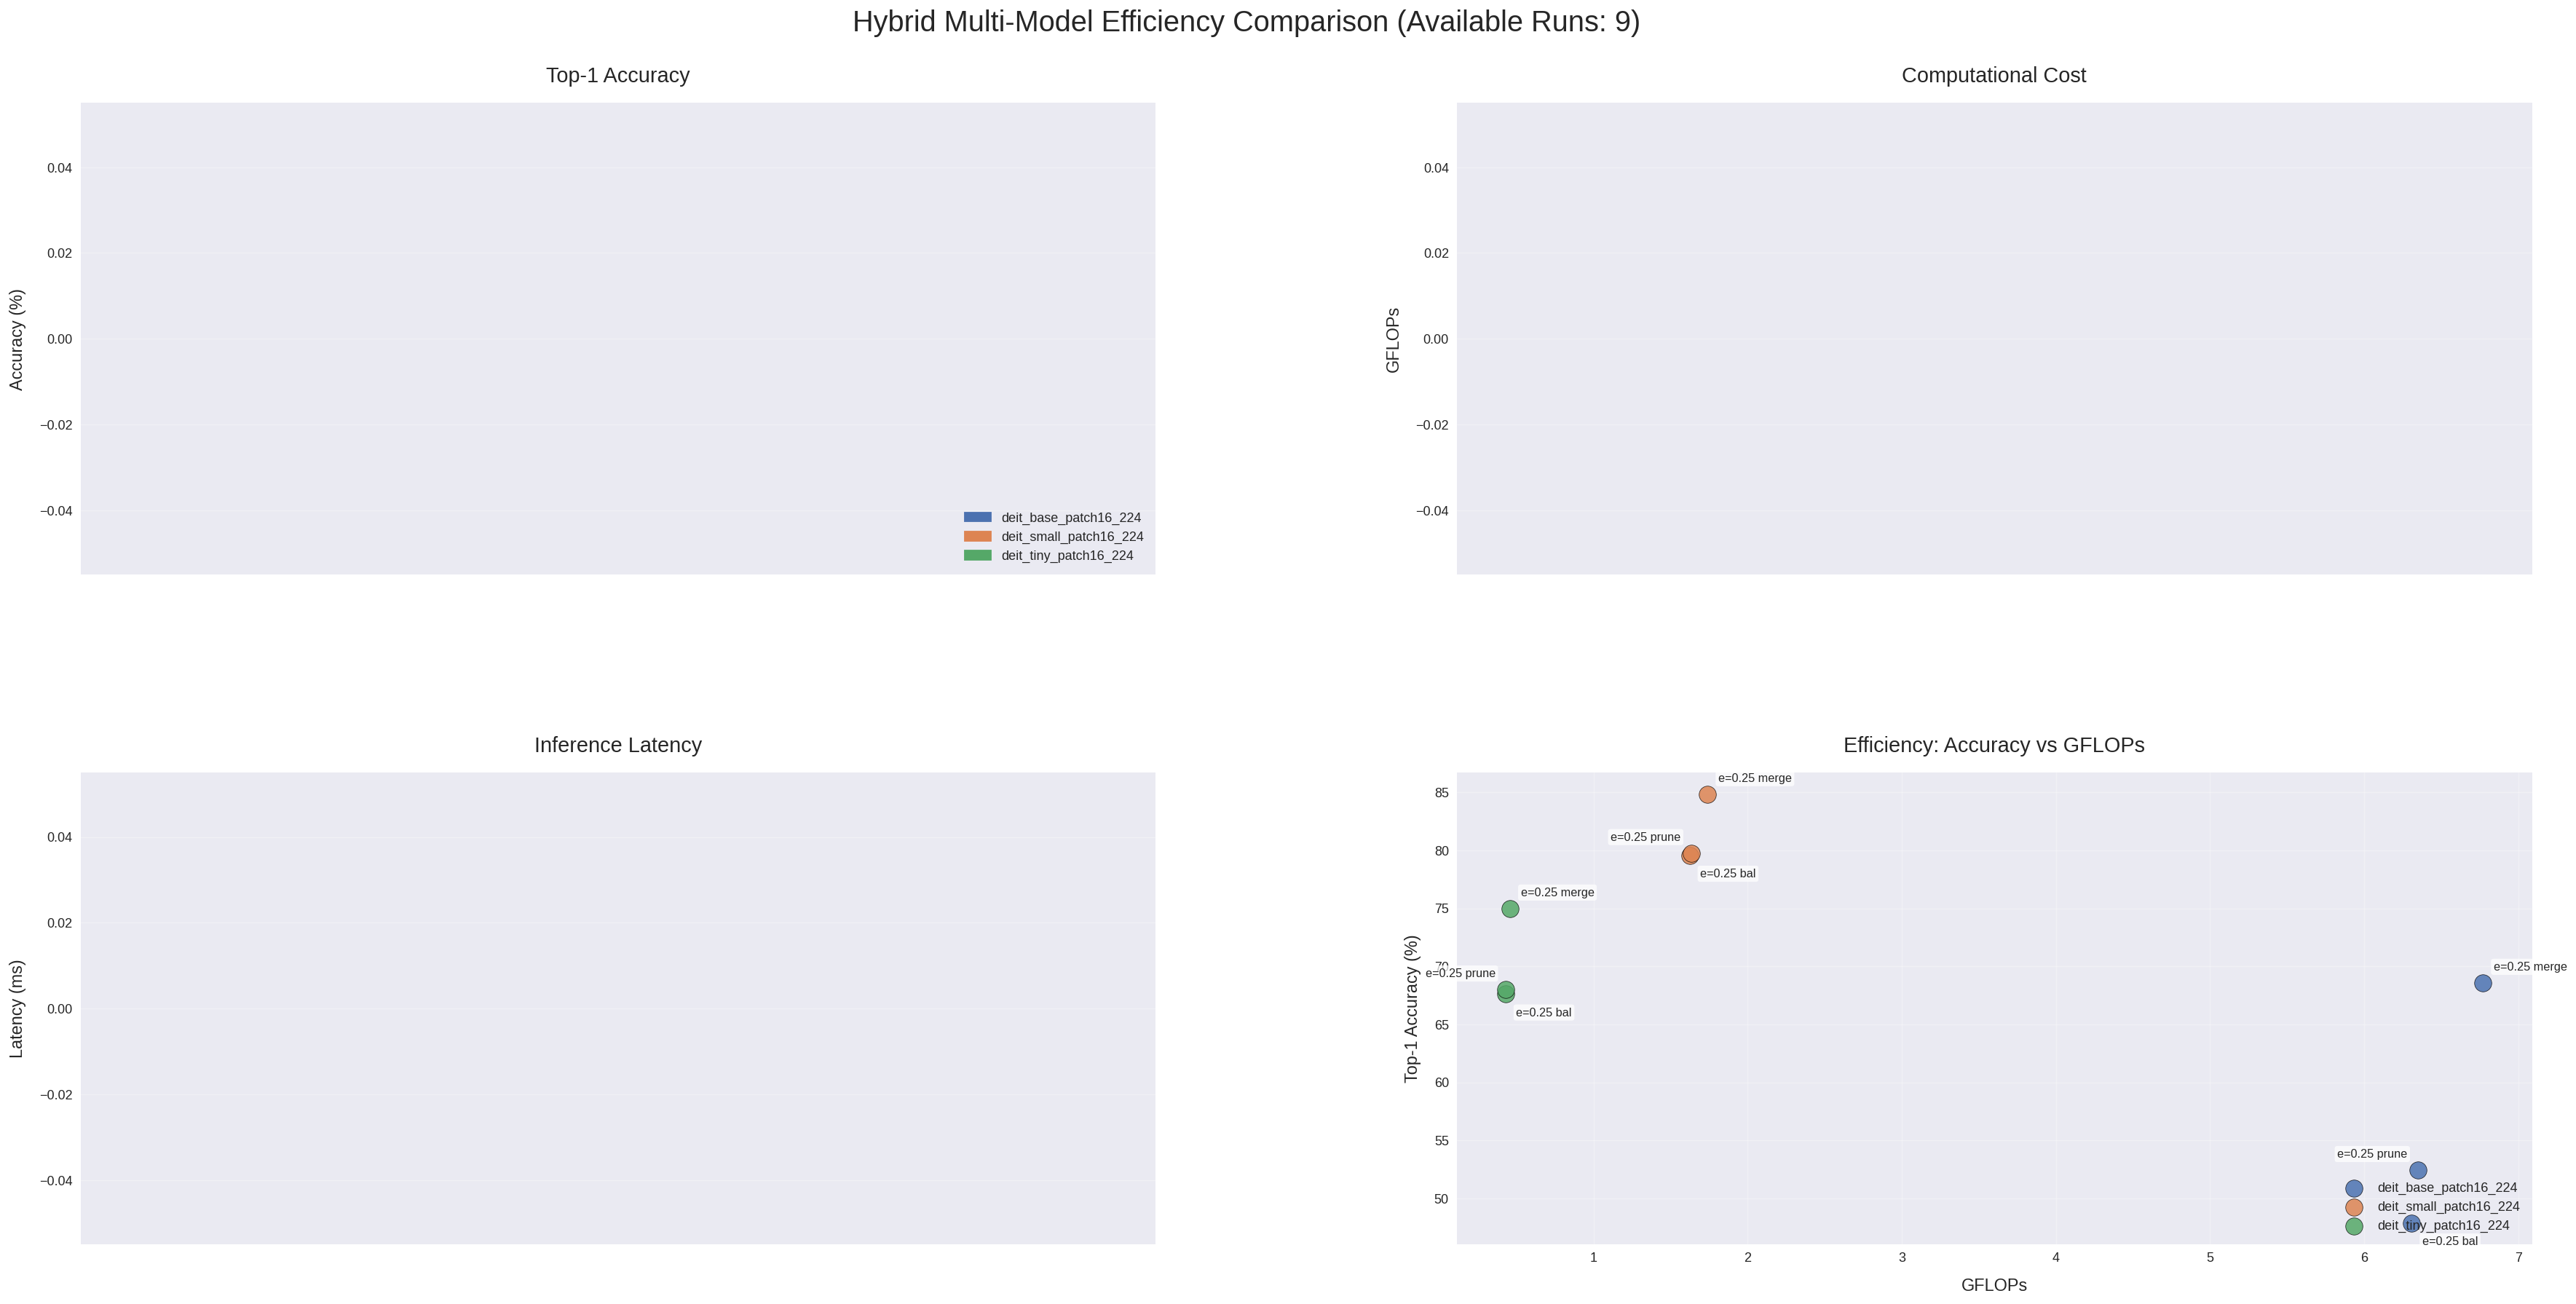


Hybrid Multi-Model Efficiency Comparison (Available Runs: 9) - Summary Table
                                         config_name                  model  params_m   gflops  acc1  latency_ms  throughput               model_id             config_key  efficiency_budget       profile reduction_loc        evit_keep_rate        tome_keep_rate
      Hybrid deit_tiny_patch16_224 eff_0.25_balanced  deit_tiny_patch16_224  5.543716 0.429446 67.62    1.107321  903.080643  deit_tiny_patch16_224      eff_0.25_balanced               0.25      balanced     [3, 6, 9]       [0.5, 0.5, 0.5]       [0.5, 0.5, 0.5]
 Hybrid deit_tiny_patch16_224 eff_0.25_pruning_heavy  deit_tiny_patch16_224  5.543716 0.431916 68.00    0.668976 1494.821265  deit_tiny_patch16_224 eff_0.25_pruning_heavy               0.25 pruning_heavy     [3, 6, 9]       [0.4, 0.4, 0.4] [0.625, 0.625, 0.625]
 Hybrid deit_tiny_patch16_224 eff_0.25_merging_heavy  deit_tiny_patch16_224  5.543716 0.459053 74.98    0.715212 1398.186477  deit_tiny_

In [23]:
# Final hybrid visualization call (works with any subset of the 27 DeiT runs already executed)
if 'results' not in globals() or not results:
    print('No results found. Run any hybrid sweep cells first.')
else:
    df_all = pd.DataFrame(results).copy()
    df_hybrid = df_all[df_all['config_name'].astype(str).str.startswith('Hybrid ')].copy()

    if df_hybrid.empty:
        print('No hybrid results found yet.')
    else:
        extracted = df_hybrid['config_name'].str.extract(
            r'^Hybrid\s+(?P<parsed_model>\S+)\s+(?P<parsed_config>eff_[0-9.]+_[a-z_]+)$'
        )
        if 'model_id' not in df_hybrid.columns:
            df_hybrid['model_id'] = extracted['parsed_model']
        else:
            df_hybrid['model_id'] = df_hybrid['model_id'].fillna(extracted['parsed_model'])

        if 'config_key' not in df_hybrid.columns:
            df_hybrid['config_key'] = extracted['parsed_config']
        else:
            df_hybrid['config_key'] = df_hybrid['config_key'].fillna(extracted['parsed_config'])

        for col in ['acc1', 'gflops', 'latency_ms', 'throughput', 'params_m']:
            if col in df_hybrid.columns:
                df_hybrid[col] = pd.to_numeric(df_hybrid[col], errors='coerce')

        plot_df = df_hybrid.dropna(subset=['acc1', 'gflops', 'latency_ms']).copy()
        if plot_df.empty:
            print('No numeric hybrid results available to plot yet.')
        else:
            compare_hybrid_configurations_spacious(
                plot_df.to_dict(orient='records'),
                title=f'Hybrid Multi-Model Efficiency Comparison (Available Runs: {len(plot_df)})'
            )

In [24]:
# Accuracy/GFLOPs analysis: rank the executed hybrid configs and report the best run
analysis_df = pd.DataFrame(results).copy() if 'results' in globals() else pd.DataFrame()
analysis_df = analysis_df[analysis_df['config_name'].astype(str).str.startswith('Hybrid ')].copy() if not analysis_df.empty else analysis_df

if analysis_df.empty:
    print('No hybrid sweep results found yet. Run the hybrid sweep cells first.')
else:
    extracted = analysis_df['config_name'].str.extract(
        r'^Hybrid\s+(?P<parsed_model>\S+)\s+(?P<parsed_config>eff_[0-9.]+_[a-z_]+)$'
    )
    if 'model_id' not in analysis_df.columns:
        analysis_df['model_id'] = extracted['parsed_model']
    else:
        analysis_df['model_id'] = analysis_df['model_id'].fillna(extracted['parsed_model'])

    if 'config_key' not in analysis_df.columns:
        analysis_df['config_key'] = extracted['parsed_config']
    else:
        analysis_df['config_key'] = analysis_df['config_key'].fillna(extracted['parsed_config'])

    if 'efficiency_budget' not in analysis_df.columns:
        analysis_df['efficiency_budget'] = pd.to_numeric(
            analysis_df['config_key'].astype(str).str.extract(r'^eff_([0-9.]+)_')[0],
            errors='coerce',
        )

    if 'profile' not in analysis_df.columns:
        analysis_df['profile'] = analysis_df['config_key'].astype(str).str.replace(
            r'^eff_[0-9.]+_', '', regex=True
        )

    for col in ['acc1', 'gflops', 'latency_ms', 'throughput', 'params_m']:
        if col in analysis_df.columns:
            analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

    analysis_df = analysis_df.dropna(subset=['acc1', 'gflops']).copy()
    if analysis_df.empty:
        print('No numeric hybrid sweep results available yet.')
    else:
        analysis_df['acc_per_gflop'] = analysis_df['acc1'] / analysis_df['gflops']
        df_rank = analysis_df.sort_values('acc_per_gflop', ascending=False).reset_index(drop=True)

        rank_cols = [
            col for col in [
                'model_id', 'efficiency_budget', 'profile', 'config_key',
                'acc1', 'gflops', 'acc_per_gflop', 'latency_ms', 'throughput', 'params_m'
            ] if col in df_rank.columns
        ]
        display(df_rank[rank_cols])

        best = df_rank.iloc[0]
        print('\n' + '=' * 90)
        print('Best Hybrid Config by Accuracy/GFLOPs')
        print('=' * 90)
        print(f"Model        : {best['model_id']}")
        print(f"Config       : {best['config_key']}")
        print(f"Top-1 Acc    : {best['acc1']:.2f}%")
        print(f"GFLOPs       : {best['gflops']:.3f}")
        print(f"Acc/GFLOP    : {best['acc_per_gflop']:.3f}")
        print(f"Latency (ms) : {best['latency_ms']:.2f}")
        print(f"Throughput   : {best['throughput']:.1f} samples/sec")
        print('=' * 90 + '\n')

,model_id,efficiency_budget,profile,config_key,acc1,gflops,acc_per_gflop,latency_ms,throughput,params_m
0,deit_tiny_patch16_224,0.25,merging_heavy,eff_0.25_merging_heavy,74.98,0.459053,163.336217,0.715212,1398.186477,5.543716
1,deit_tiny_patch16_224,0.25,balanced,eff_0.25_balanced,67.62,0.429446,157.458838,1.107321,903.080643,5.543716
2,deit_tiny_patch16_224,0.25,pruning_heavy,eff_0.25_pruning_heavy,68.00,0.431916,157.438102,0.668976,1494.821265,5.543716
3,deit_small_patch16_224,0.25,balanced,eff_0.25_balanced,79.58,1.624015,49.002015,1.192913,838.283807,21.704164
4,deit_small_patch16_224,0.25,pruning_heavy,eff_0.25_pruning_heavy,79.76,1.634028,48.811894,1.243047,804.474665,21.704164
5,deit_small_patch16_224,0.25,merging_heavy,eff_0.25_merging_heavy,84.84,1.740630,48.740965,1.342566,744.842359,21.704164
6,deit_base_patch16_224,0.25,merging_heavy,eff_0.25_merging_heavy,68.58,6.772198,10.126697,4.816914,207.601807,85.875556
7,deit_base_patch16_224,0.25,pruning_heavy,eff_0.25_pruning_heavy,52.44,6.349183,8.259331,4.529806,220.760026,85.875556
8,deit_base_patch16_224,0.25,balanced,eff_0.25_balanced,47.88,6.309043,7.589106,4.532464,220.630538,85.875556



Best Hybrid Config by Accuracy/GFLOPs
Model        : deit_tiny_patch16_224
Config       : eff_0.25_merging_heavy
Top-1 Acc    : 74.98%
GFLOPs       : 0.459
Acc/GFLOP    : 163.336
Latency (ms) : 0.72
Throughput   : 1398.2 samples/sec



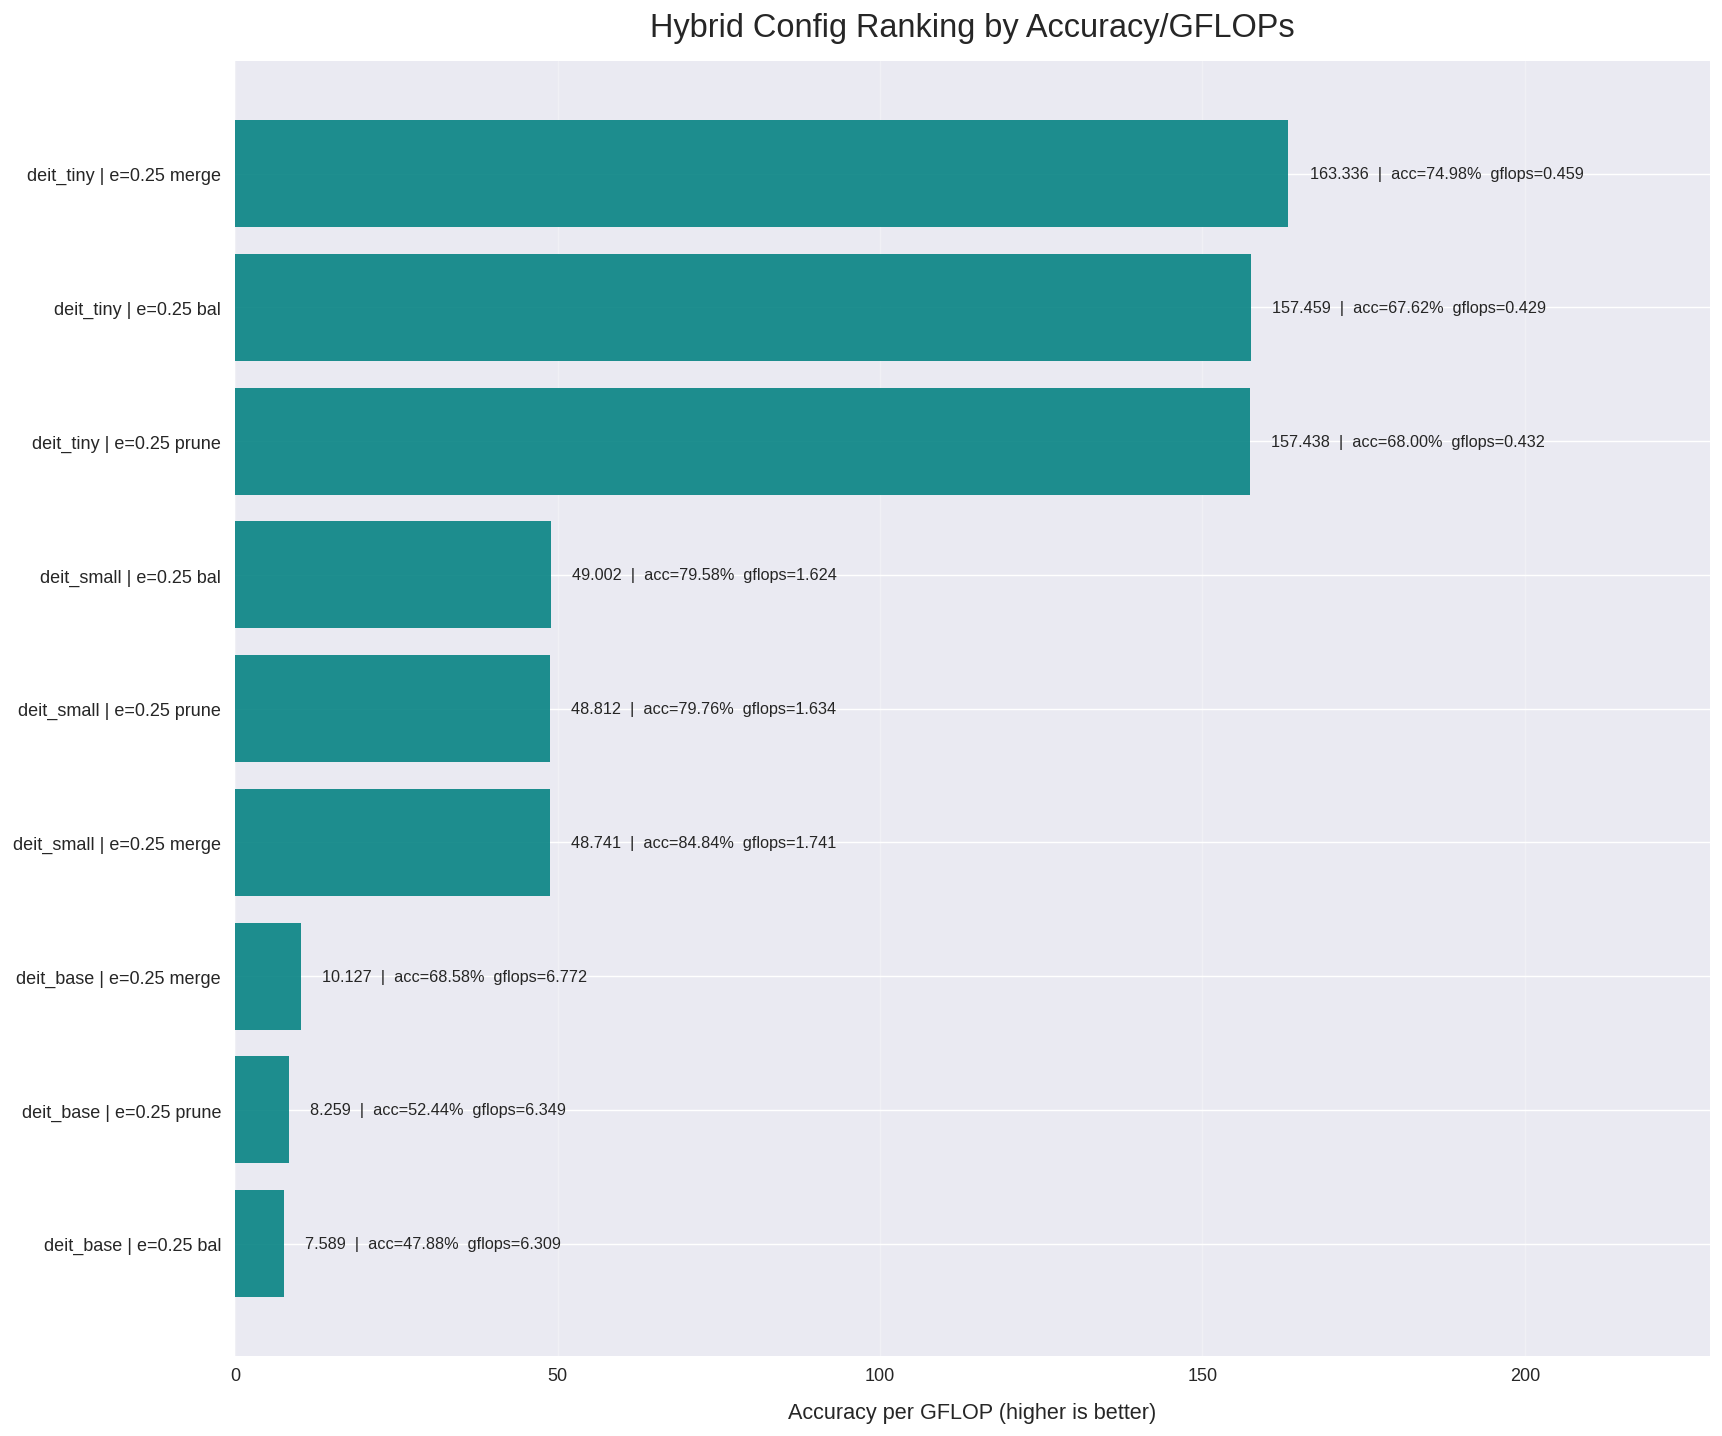

In [25]:
# Accuracy/GFLOPs ranking graph for the executed hybrid configs
if 'df_rank' in globals() and isinstance(df_rank, pd.DataFrame) and not df_rank.empty:
    rank_plot_df = df_rank.copy()
else:
    rank_plot_df = pd.DataFrame(results).copy() if 'results' in globals() else pd.DataFrame()
    rank_plot_df = rank_plot_df[rank_plot_df['config_name'].astype(str).str.startswith('Hybrid ')].copy() if not rank_plot_df.empty else rank_plot_df

    if not rank_plot_df.empty:
        extracted = rank_plot_df['config_name'].str.extract(
            r'^Hybrid\s+(?P<parsed_model>\S+)\s+(?P<parsed_config>eff_[0-9.]+_[a-z_]+)$'
        )
        if 'model_id' not in rank_plot_df.columns:
            rank_plot_df['model_id'] = extracted['parsed_model']
        else:
            rank_plot_df['model_id'] = rank_plot_df['model_id'].fillna(extracted['parsed_model'])

        if 'config_key' not in rank_plot_df.columns:
            rank_plot_df['config_key'] = extracted['parsed_config']
        else:
            rank_plot_df['config_key'] = rank_plot_df['config_key'].fillna(extracted['parsed_config'])

        for col in ['acc1', 'gflops']:
            if col in rank_plot_df.columns:
                rank_plot_df[col] = pd.to_numeric(rank_plot_df[col], errors='coerce')

        rank_plot_df = rank_plot_df.dropna(subset=['acc1', 'gflops']).copy()
        if not rank_plot_df.empty:
            rank_plot_df['acc_per_gflop'] = rank_plot_df['acc1'] / rank_plot_df['gflops']
            rank_plot_df = rank_plot_df.sort_values('acc_per_gflop', ascending=False).reset_index(drop=True)

if rank_plot_df.empty:
    print('No hybrid sweep results found yet. Run the hybrid sweep and analysis cells first.')
else:
    plt.close('all')
    fig, ax = plt.subplots(figsize=(18, 12), dpi=130)
    fig.subplots_adjust(left=0.34, right=0.97, top=0.91, bottom=0.08)

    short_labels = _shorten_hybrid_labels(rank_plot_df['config_key'].tolist())
    labels = [
        f"{model_id.replace('_patch16_224', '')} | {label}"
        for model_id, label in zip(rank_plot_df['model_id'], short_labels)
    ]

    y = np.arange(len(rank_plot_df))
    values = rank_plot_df['acc_per_gflop'].astype(float).values

    bars = ax.barh(y, values, color='teal', alpha=0.88)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Accuracy per GFLOP (higher is better)', fontsize=12, labelpad=10)
    ax.set_title('Hybrid Config Ranking by Accuracy/GFLOPs', fontsize=18, pad=14)
    ax.grid(True, axis='x', alpha=0.30)
    ax.tick_params(axis='y', pad=8)
    ax.tick_params(axis='x', pad=6)

    xmax = float(values.max()) if len(values) else 0.0
    xpad = xmax * 0.02 if xmax > 0 else 0.02
    for i, (bar, value) in enumerate(zip(bars, values)):
        acc = float(rank_plot_df.iloc[i]['acc1'])
        gflops = float(rank_plot_df.iloc[i]['gflops'])
        text = f"{value:.3f}  |  acc={acc:.2f}%  gflops={gflops:.3f}"
        ax.text(value + xpad, bar.get_y() + bar.get_height() / 2, text, va='center', fontsize=9)

    ax.set_xlim(0, xmax + xpad * 20)
    plt.show()